# Image Retrieval & VLM Generation Test
Pull an image chunk from Qdrant, display it, and test VisionGenerator end-to-end.

In [2]:
import sys
sys.path.insert(0, '..')  # src/ is parent when running from notebooks/

from pathlib import Path
from config.config import AdvancedConfig

config = AdvancedConfig()
print('DATA_DIR:', config.DATA_DIR)
print('Collection:', config.VECTOR_DB_COLLECTION)

DATA_DIR: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data
Collection: advanced_multimodal


## 1. Connect to Qdrant and browse image chunks

In [4]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Filter, FieldCondition, MatchValue

print('VECTOR_DB_PATH:', config.VECTOR_DB_PATH)
print('DATA_DIR:', config.DATA_DIR)

client = QdrantClient(path=config.VECTOR_DB_PATH)

# Count by type
for chunk_type in ('text', 'page_image', 'evidence'):
    result = client.count(
        collection_name=config.VECTOR_DB_COLLECTION,
        count_filter=Filter(
            must=[FieldCondition(key='type', match=MatchValue(value=chunk_type))]
        ),
        exact=True,
    )
    print(f'{chunk_type}: {result.count}')

VECTOR_DB_PATH: /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant
DATA_DIR: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data


RuntimeError: Storage folder /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant is already accessed by another instance of Qdrant client. If you require concurrent access, use Qdrant server instead.

In [3]:
# Fetch a few page_image chunks to pick one
page_image_results, _ = client.scroll(
    collection_name=config.VECTOR_DB_COLLECTION,
    scroll_filter=Filter(
        must=[FieldCondition(key='type', match=MatchValue(value='page_image'))]
    ),
    limit=5,
    with_payload=True,
    with_vectors=False,
)

for r in page_image_results:
    print(r.id, r.payload)

5311 {'text': 'Page 0 of 05-03-18-political-release', 'type': 'page_image', 'image_path': 'train/page_images_train/05-03-18-political-release_0.jpg', 'doc_name': '05-03-18-political-release', 'page_num': 0}
5312 {'text': 'Page 1 of 05-03-18-political-release', 'type': 'page_image', 'image_path': 'train/page_images_train/05-03-18-political-release_1.jpg', 'doc_name': '05-03-18-political-release', 'page_num': 1}
5313 {'text': 'Page 10 of 05-03-18-political-release', 'type': 'page_image', 'image_path': 'train/page_images_train/05-03-18-political-release_10.jpg', 'doc_name': '05-03-18-political-release', 'page_num': 10}
5314 {'text': 'Page 11 of 05-03-18-political-release', 'type': 'page_image', 'image_path': 'train/page_images_train/05-03-18-political-release_11.jpg', 'doc_name': '05-03-18-political-release', 'page_num': 11}
5315 {'text': 'Page 12 of 05-03-18-political-release', 'type': 'page_image', 'image_path': 'train/page_images_train/05-03-18-political-release_12.jpg', 'doc_name': '0

## 2. Display the image

Relative path: train/page_images_train/05-03-18-political-release_0.jpg
Absolute path: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/train/page_images_train/05-03-18-political-release_0.jpg
Exists: True


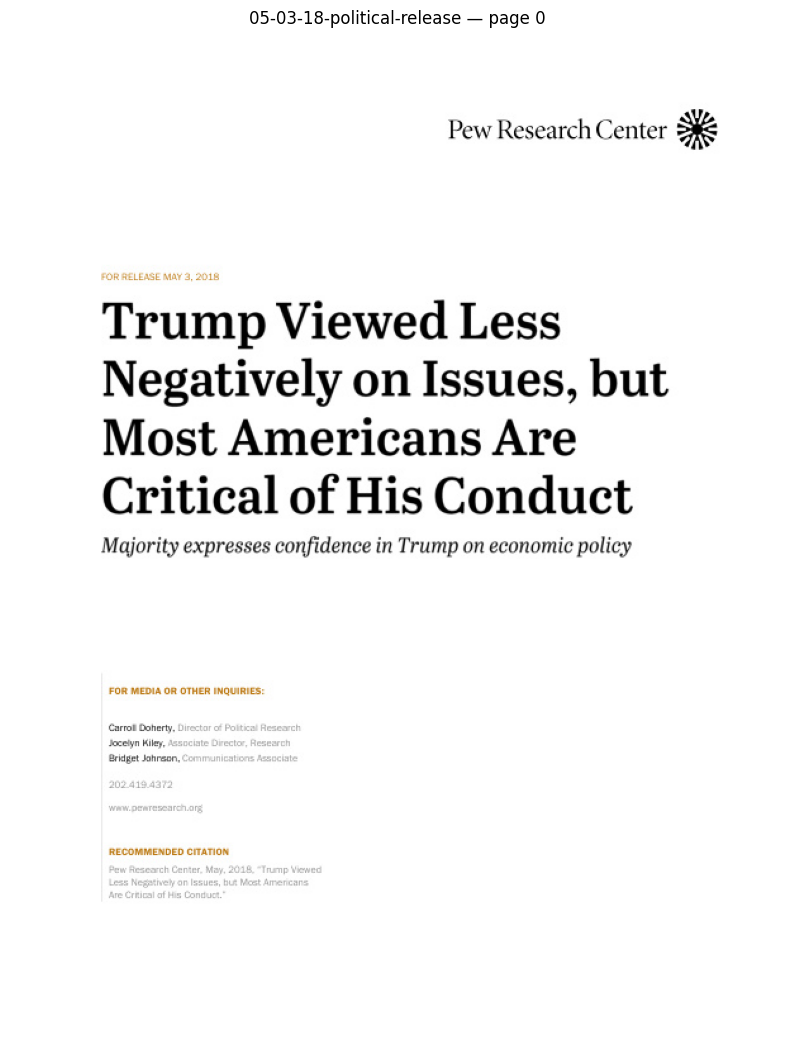

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Pick the first page_image result
chosen = page_image_results[0]
rel_path = chosen.payload['image_path']   # relative to DATA_DIR
abs_path = config.DATA_DIR / rel_path

print('Relative path:', rel_path)
print('Absolute path:', abs_path)
print('Exists:', abs_path.exists())

img = Image.open(abs_path)
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis('off')
plt.title(f"{chosen.payload.get('doc_name')} — page {chosen.payload.get('page_num')}")
plt.show()

## 3. Ask the VLM a question about the image

In [5]:
from generation.generator import VisionGenerator

vlm = VisionGenerator(
    base_url=config.OLLAMA_BASE_URL,
    model=config.LLM_MODEL,
)
print('VLM ready:', vlm.model)

VLM ready: qwen3-vl:4b-instruct


In [6]:
# Test image call (think=False, num_predict=2048)
question = 'What is shown in this image? Summarise briefly.'

answer = vlm.generate_with_images(
    question=question,
    image_paths=[str(abs_path)],
    text_context='',
)
print('=== IMAGE ANSWER ===')
print(answer)

=== IMAGE ANSWER ===
['Pew Research Center', 'Trump Viewed Less Negatively on Issues, but Most Americans Are Critical of His Conduct', 'Majority expresses confidence in Trump on economic policy']


In [17]:
# Test text call (think=True, num_predict=2048) — verify no empty response
text_context = chosen.payload.get('text', f"Page {chosen.payload.get('page_num')} of {chosen.payload.get('doc_name')}")

text_answer = vlm.generate(
    question='What document and page does this context come from?',
    context=text_context,
)
print('=== TEXT ANSWER ===')
print(text_answer)

=== TEXT ANSWER ===
['05-03-18-political-release', '0']


## 4. Test with an evidence chunk

In [7]:
evidence_results, _ = client.scroll(
    collection_name=config.VECTOR_DB_COLLECTION,
    scroll_filter=Filter(
        must=[FieldCondition(key='type', match=MatchValue(value='evidence'))]
    ),
    limit=3,
    with_payload=True,
    with_vectors=False,
)

ev = evidence_results[0]
print('Question embedded:', ev.payload.get('text'))
print('Image paths:', ev.payload.get('image_path'))

Question embedded: How many parts has the prefix N in the packages?
Image paths: ['train/images_train/DSA-278777/0475_How_many_parts_has_the_prefix_N_in_the_packages/DSA-278777__page_2__map_0__match_0.png']


Exists: True | /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/train/images_train/DSA-278777/0475_How_many_parts_has_the_prefix_N_in_the_packages/DSA-278777__page_2__map_0__match_0.png


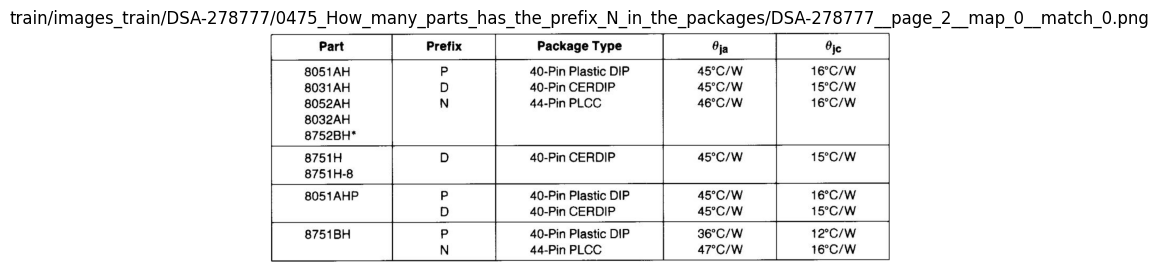

In [ ]:
# Display evidence image(s)
ev_paths = ev.payload['image_path']
if isinstance(ev_paths, str):
    ev_paths = [ev_paths]

for ep in ev_paths:
    ep_abs = config.DATA_DIR / ep
    print('Exists:', ep_abs.exists(), '|', ep_abs)
    if ep_abs.exists():
        img = Image.open(ep_abs)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(ep)
        plt.show()

In [9]:
# Inspect image size before sending to VLM
for ep in ev_paths:
    ep_abs = config.DATA_DIR / ep
    if ep_abs.exists():
        img_check = Image.open(ep_abs)
        print(f'Size: {img_check.size}  Mode: {img_check.mode}  File size: {ep_abs.stat().st_size / 1024:.1f} KB')
        print(f'Path: {ep_abs}')

Size: (1170, 435)  Mode: RGB  File size: 200.8 KB
Path: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/train/images_train/DSA-278777/0475_How_many_parts_has_the_prefix_N_in_the_packages/DSA-278777__page_2__map_0__match_0.png


In [6]:
# Ask the actual question from the evidence chunk
ev_question = ev.payload['text']
ev_abs_paths = [str(config.DATA_DIR / p) for p in ev_paths if (config.DATA_DIR / p).exists()]

ev_answer = vlm.generate_with_images(
    question=ev_question,
    image_paths=ev_abs_paths,
    text_context='',
)
print('Question:', ev_question)
print('Answer:', ev_answer)

NameError: name 'ev_paths' is not defined

In [11]:
# Test local Ollama at localhost:11434 (AnythingLLM's model, no API key needed)
import importlib, generation.generator as _gmod
importlib.reload(_gmod)
from generation.generator import VisionGenerator, _encode_image

vlm_local = VisionGenerator(
    base_url='http://localhost:11434',
    model='qwen3-vl:4b-instruct',
    api_key=None,
)

raw_paths = [str(config.DATA_DIR / p) for p in ev_paths if (config.DATA_DIR / p).exists()]

# Text call
text_ans = vlm_local.generate(
    question='What is the capital of France?',
    context='France is a country in Western Europe. Its capital city is Paris.',
)
print('Text answer:', text_ans)

# Image call
img_ans = vlm_local.generate_with_images(
    question=ev_question,
    image_paths=raw_paths,
    text_context='',
)
print('Question:', ev_question)
print('Image answer:', img_ans)

Error generating response: "qwen3-vl:4b-instruct" does not support thinking (status code: 400)


Text answer: Error generating response: "qwen3-vl:4b-instruct" does not support thinking (status code: 400)
Question: How many parts has the prefix N in the packages?
Image answer: ['8052AH', '8751BH']


## 5. Simulate a full pipeline retrieval → generation

In [1]:
import sys
sys.path.insert(0, '..')  # src/ is parent when running from notebooks/

from pathlib import Path
from config.config import AdvancedConfig

config = AdvancedConfig()
print('DATA_DIR:', config.DATA_DIR)
print('Collection:', config.VECTOR_DB_COLLECTION)

DATA_DIR: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data
Collection: advanced_multimodal


In [2]:
# Run a query through the real pipeline (index must already be built)
import sys
sys.path.insert(0, '..')

from pipelines.advanced_pipeline import AdvancedRAGPipeline

pipeline = AdvancedRAGPipeline(config)
pipeline.build_index(force_rebuild=False)   # load existing index
pipeline.initialize_components()

/opt/homebrew/Caskroom/miniconda/base/envs/dat540/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pipelines.advanced_pipeline:Building multimodal index with AdvancedConfig...
INFO:pipelines.advanced_pipeline:Initialising embedder: jinaai/jina-clip-v2
INFO:indexing.embedder:Loading embedding model: jinaai/jina-clip-v2
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: jinaai/jina-clip-v2
`torch_dtype` is deprecated! Use `dtype` instead!
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configuration_clip:`text_config` is `None`. Initializing the `JinaCLIPTextConfig` with default values.
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configu


[OK] Embedding model loaded. Dimension: 1024
Initializing local Qdrant at /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant...


INFO:pipelines.advanced_pipeline:Existing collection has 11839 documents
INFO:pipelines.advanced_pipeline:Loading existing multimodal index...
INFO:data.chunk_loader:Loading pre-processed chunks from /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/preprocessed/chunks_semantic.json



[OK] Local Qdrant initialized


INFO:data.chunk_loader:Loaded 127 documents from JSON
INFO:data.chunk_loader:✓ Extracted 5311 chunks from 127 documents
INFO:data.chunk_loader:  Average chunks per document: 41.8
INFO:pipelines.base_pipeline:Building hybrid BM25 + dense retriever...
INFO:indexing.hybrid_retriever:Building BM25 index over 5311 chunks...
INFO:indexing.hybrid_retriever:BM25 index built.
INFO:pipelines.advanced_pipeline:Index loaded in 42.01s
INFO:pipelines.advanced_pipeline:Initialising generator (VisionGenerator): qwen3.5:122b
INFO:generation.generator:Loaded API key: sk-f937f3b...
INFO:generation.generator:Initialized Ollama client for model: qwen3.5:122b
INFO:pipelines.advanced_pipeline:Initialising query technique: standard


In [3]:
from qdrant_client.http.models import Filter, FieldCondition, MatchValue

evidence_results, _ = pipeline.vector_db.client.scroll(
    collection_name=config.VECTOR_DB_COLLECTION,
    scroll_filter=Filter(
        must=[FieldCondition(key='type', match=MatchValue(value='evidence'))]
    ),
    limit=3,
    with_payload=True,
    with_vectors=False,
)

ev = evidence_results[0]
ev_paths = ev.payload['image_path']
if isinstance(ev_paths, str):
    ev_paths = [ev_paths]
ev_question = ev.payload['text']
ev_abs_paths = [str(config.DATA_DIR / p) for p in ev_paths if (config.DATA_DIR / p).exists()]



In [4]:
from generation.generator import VisionGenerator

vlm = VisionGenerator(
    base_url=config.OLLAMA_BASE_URL,
    model=config.LLM_MODEL,
)
print('VLM ready:', vlm.model)

# Text call
text_ans = vlm.generate(
    question='What is the capital of France?',
    context='France is a country in Western Europe. Its capital city is Paris.',
    think=True
)
print('Text answer:', text_ans)

raw_paths = [str(config.DATA_DIR / p) for p in ev_paths if (config.DATA_DIR / p).exists()]

img_ans = vlm.generate_with_images(
    question=ev_question,
    image_paths=raw_paths,
    text_context='',
)
print('Question:', ev_question)
print('Image answer:', img_ans)

INFO:generation.generator:Loaded API key: sk-f937f3b...
INFO:generation.generator:Initialized Ollama client for model: qwen3.5:122b


VLM ready: qwen3.5:122b


INFO:httpx:HTTP Request: POST https://ollama.ux.uis.no/api/chat "HTTP/1.1 200 OK"
INFO:generation.generator:resp: model='qwen3.5:122b' created_at='2026-04-10T12:33:04.107288434Z' done=True done_reason='stop' total_duration=10511742671 load_duration=340674974 prompt_eval_count=193 prompt_eval_duration=608266218 eval_count=278 eval_duration=9272525618 message=Message(role='assistant', content='Paris', thinking='Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Task: Answer the question based *only* on the provided context.\n    *   Constraints: Concise, no preamble, no explanation, no rephrasing. If multiple answers, use list format. For yes/no, use "Yes" or "No".\n    *   Context: "France is a country in Western Europe. Its capital city is Paris."\n    *   Question: "What is the capital of France?"\n\n2.  **Analyze the Context:**\n    *   Sentence 1: "France is a country in Western Europe."\n    *   Sentence 2: "Its capital city is Paris." ("Its" refers to France).\n\n3.  **Det

Text answer: Paris


INFO:httpx:HTTP Request: POST https://ollama.ux.uis.no/api/chat "HTTP/1.1 200 OK"
INFO:generation.generator:resp: model='qwen3.5:122b' created_at='2026-04-10T12:33:06.262255668Z' done=True done_reason='stop' total_duration=1848985144 load_duration=459343537 prompt_eval_count=547 prompt_eval_duration=1224212379 eval_count=2 eval_duration=35213020 message=Message(role='assistant', content='2', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None


Question: How many parts has the prefix N in the packages?
Image answer: 2


In [ ]:
# Test local Ollama at localhost:11434 (AnythingLLM's model, no API key needed)
import importlib, generation.generator as _gmod
importlib.reload(_gmod)
from generation.generator import VisionGenerator, _encode_image

vlm_local = VisionGenerator(
    base_url='http://localhost:11434',
    model='qwen3-vl:4b-instruct',
    api_key='TY9D78Y-T6EMZ4F-NP45H4Q-A61G6ZW',
)

raw_paths = [str(config.DATA_DIR / p) for p in ev_paths if (config.DATA_DIR / p).exists()]

# Text call
text_ans = vlm_local.generate(
    question='What is the capital of France?',
    context='France is a country in Western Europe. Its capital city is Paris.',
    think=False,)
print('Text answer:', text_ans)

# Image call
img_ans = vlm_local.generate_with_images(
    question=ev_question,
    image_paths=raw_paths,
    text_context='',
)
print('Question:', ev_question)
print('Image answer:', img_ans)

SyntaxError: '(' was never closed (424274729.py, line 15)

## 6. Retrieval Evaluation on Train Questions

Loop through a subset of train questions, embed each with Jina CLIP v2, retrieve from the multimodal Qdrant collection, and inspect what comes back.

In [1]:
import sys
sys.path.insert(0, '..')  # src/ is parent when running from notebooks/

from pathlib import Path
from config.config import AdvancedConfig

config = AdvancedConfig()
print('DATA_DIR:', config.DATA_DIR)
print('Collection:', config.VECTOR_DB_COLLECTION)

DATA_DIR: /Users/bebs/Documents/School/DAT 560/DAT560project/src/data
Collection: advanced_multimodal


In [2]:
import json
from pathlib import Path

# ------------------------------------------------------------------
# Load a subset of train questions
# ------------------------------------------------------------------
SUBSET_SIZE = 20

questions = []
with open(config.TRAIN_JSONL) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        entry = json.loads(line)
        if entry.get("question"):
            questions.append(entry)
        if len(questions) >= SUBSET_SIZE:
            break

print(f"Loaded {len(questions)} questions")
print(f"\nExample entry:")
q0 = questions[0]
print(f"  question_id : {q0['question_id']}")
print(f"  question    : {q0['question']}")
print(f"  page_ids    : {q0['page_ids']}")
print(f"  types       : {q0['types']}")
print(f"  pdf_path    : {q0['pdf_path']}")


Loaded 20 questions

Example entry:
  question_id : 475
  question    : How many parts has the prefix N in the packages?
  page_ids    : [2]
  types       : ['Pure-text (Plain-text)', 'Table']
  pdf_path    : pdf_train/DSA-278777.pdf


In [3]:
# ------------------------------------------------------------------
# Diagnostic: check what scores page_image chunks get for a sample query
# ------------------------------------------------------------------
sample_q = questions[0]   # Q1: "How many parts has the prefix N in the packages?"
query_emb = pipeline.embedder.embed_query(sample_q["question"])

# Retrieve top-5 text only
text_results = pipeline.vector_db.retrieve(query_emb, top_k=5, allowed_types=["text"])
print("Top-5 TEXT scores:")
for r in text_results:
    print(f"  score={r['score']:.4f}  doc={r['payload'].get('pdf_name','')}")

# Retrieve top-5 page_image only
img_results = pipeline.vector_db.retrieve(query_emb, top_k=5, allowed_types=["page_image"])
print("\nTop-5 PAGE_IMAGE scores:")
for r in img_results:
    print(f"  score={r['score']:.4f}  doc={r['payload'].get('doc_name','')}  page={r['payload'].get('page_num')}")

expected_stem = "DSA-278777"
print(f"\nExpected doc: {expected_stem}  page: {sample_q['page_ids']}")


NameError: name 'pipeline' is not defined

In [4]:
# ------------------------------------------------------------------
# Load the existing multimodal index (no rebuild)
# ------------------------------------------------------------------
import sys
sys.path.insert(0, '..')

from pipelines.advanced_pipeline import AdvancedRAGPipeline

pipeline = AdvancedRAGPipeline(config)
pipeline.build_index(force_rebuild=False)   # reuse already-built index

doc_count = pipeline.vector_db.count_documents()
print(f"Collection '{config.VECTOR_DB_COLLECTION}' has {doc_count} documents")


/opt/homebrew/Caskroom/miniconda/base/envs/dat540/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pipelines.advanced_pipeline:Building multimodal index with AdvancedConfig...
INFO:pipelines.advanced_pipeline:Initialising embedder: jinaai/jina-clip-v2
INFO:indexing.embedder:Loading embedding model: jinaai/jina-clip-v2
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: jinaai/jina-clip-v2
`torch_dtype` is deprecated! Use `dtype` instead!
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configuration_clip:`text_config` is `None`. Initializing the `JinaCLIPTextConfig` with default values.
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configu


[OK] Embedding model loaded. Dimension: 1024
Initializing local Qdrant at /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant...


INFO:pipelines.advanced_pipeline:Existing collection has 11839 documents
INFO:pipelines.advanced_pipeline:Loading existing multimodal index...
INFO:data.chunk_loader:Loading pre-processed chunks from /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/preprocessed/chunks_semantic.json



[OK] Local Qdrant initialized


INFO:data.chunk_loader:Loaded 127 documents from JSON
INFO:data.chunk_loader:✓ Extracted 5311 chunks from 127 documents
INFO:data.chunk_loader:  Average chunks per document: 41.8
INFO:pipelines.base_pipeline:Building hybrid BM25 + dense retriever...
INFO:indexing.hybrid_retriever:Building BM25 index over 5311 chunks...
INFO:indexing.hybrid_retriever:BM25 index built.
INFO:pipelines.advanced_pipeline:Index loaded in 136.45s


Collection 'advanced_multimodal' has 11839 documents


In [6]:
# ------------------------------------------------------------------
# Retrieve top-K results using split retrieval (text + page_image separately)
# to prevent text-text similarity from crowding out cross-modal image results.
# ------------------------------------------------------------------
from pathlib import Path

TOP_K_TEXT  = 3    # text chunks per query
TOP_K_IMAGE = 2    # page_image chunks per query
DISPLAY_N   = 5    # questions to print in detail

all_retrievals = []
results_summary = []

for i, q in enumerate(questions):
    question_text  = q["question"]
    pdf_stem       = Path(q["pdf_path"]).stem
    relevant_pages = set(q.get("page_ids") or [])
    question_id    = q.get("question_id")

    # ---- Split retrieval: text + page_image budgets ----
    query_emb = pipeline.embedder.embed_query(question_text)
    retrieved  = pipeline.vector_db.retrieve_split(
        query_emb,
        top_k_text=TOP_K_TEXT,
        top_k_image=TOP_K_IMAGE,
    )
    all_retrievals.append(retrieved)

    # ---- Hit detection ----
    hit_text     = False
    hit_page_img = False

    for r in retrieved:
        p = r.get("payload", {})
        t = p.get("type", "text")

        if t == "text":
            doc   = p.get("pdf_name", "").replace(".pdf", "")
            pages = set(p.get("page_numbers") or [])
            if doc == pdf_stem and pages & relevant_pages:
                hit_text = True

        elif t == "page_image":
            if p.get("doc_name") == pdf_stem and p.get("page_num") in relevant_pages:
                hit_page_img = True

    any_hit = hit_text or hit_page_img
    results_summary.append({
        "question_id" : question_id,
        "hit_text"    : hit_text,
        "hit_page_img": hit_page_img,
        "any_hit"     : any_hit,
    })

   
    print(f"\n{'='*72}")
    print(f"Q{i+1} [id={question_id}]: {question_text}")
    print(f"  Expected: {pdf_stem}.pdf  |  pages={sorted(relevant_pages)}")
    print(f"  Retrieved (text≤{TOP_K_TEXT} + image≤{TOP_K_IMAGE}):")
    for j, r in enumerate(retrieved):
        p = r.get("payload", {})
        t = p.get("type", "text")
        score = r.get("score", 0.0)
        if t == "text":
            print(f"    [{j+1}] text       score={score:.3f}  doc={p.get('pdf_name','?')}  pages={p.get('page_numbers')}")
        elif t == "page_image":
            print(f"    [{j+1}] page_image score={score:.3f}  doc={p.get('doc_name')}  page={p.get('page_num')}")
    marker = "HIT" if any_hit else "MISS"
    print(f"  → [{marker}]  text={hit_text}  page_image={hit_page_img}")

print(f"\nDone: {len(questions)} questions processed")


Batches: 100%|██████████| 1/1 [00:11<00:00, 11.62s/it]



Q1 [id=475]: How many parts has the prefix N in the packages?
  Expected: DSA-278777.pdf  |  pages=[2]
  Retrieved (text≤3 + image≤2):
    [1] text       score=0.353  doc=NETFLIX_2015_10K.pdf  pages=[18, 19]
    [2] text       score=0.348  doc=welcome-to-nus.pdf  pages=[15, 16, 17]
    [3] text       score=0.347  doc=NIKE_2021_10K.pdf  pages=[26]
    [4] page_image score=0.244  doc=NETFLIX_2015_10K  page=67
    [5] page_image score=0.233  doc=Sinopolis-Chengdu  page=53
  → [MISS]  text=False  page_image=False


Batches: 100%|██████████| 1/1 [00:18<00:00, 18.05s/it]



Q2 [id=510]: What DNA repair mechanisms does Figure 11 demonstrate?
  Expected: f1f5242528411b262be447e61e2eb10f.pdf  |  pages=[17]
  Retrieved (text≤3 + image≤2):
    [1] text       score=0.738  doc=f1f5242528411b262be447e61e2eb10f.pdf  pages=[17, 18]
    [2] text       score=0.724  doc=f1f5242528411b262be447e61e2eb10f.pdf  pages=[17]
    [3] text       score=0.663  doc=f1f5242528411b262be447e61e2eb10f.pdf  pages=[17, 18]
    [4] page_image score=0.390  doc=f1f5242528411b262be447e61e2eb10f  page=17
    [5] page_image score=0.372  doc=f1f5242528411b262be447e61e2eb10f  page=16
  → [HIT]  text=True  page_image=True


Batches: 100%|██████████| 1/1 [00:10<00:00, 10.24s/it]


...


Q18 [id=354]: By what percentage has gross profit increased in Q1 of 2023 compared to Q1 of 2022?
  Expected: q1-2023-bilibili-inc-investor-presentation.pdf  |  pages=[4]
  Retrieved (text≤3 + image≤2):
    [1] text       score=0.569  doc=COSTCO_2021_10K.pdf  pages=[26, 27]
    [2] text       score=0.537  doc=NIKE_2021_10K.pdf  pages=[35, 36]
    [3] text       score=0.533  doc=COSTCO_2021_10K.pdf  pages=[22, 23, 24, 25]
    [4] page_image score=0.308  doc=q1-2023-bilibili-inc-investor-presentation  page=18
    [5] page_image score=0.250  doc=q1-2023-bilibili-inc-investor-presentation  page=16
  → [MISS]  text=False  page_image=False


Batches: 100%|██████████| 1/1 [00:06<00:00,  6.55s/it]



Q19 [id=303]: What multiple of the 2014 e-commerce sales was achieved in 2018?
  Expected: ecommerceopportunityindia-141124010546-conversion-gate01_95.pdf  |  pages=[11]
  Retrieved (text≤3 + image≤2):
    [1] text       score=0.481  doc=Campaign_038_Introducing_AC_Whitepaper_v5e.pdf  pages=[10, 11]
    [2] text       score=0.461  doc=ecommerceopportunityindia-141124010546-conversion-gate01_95.pdf  pages=[1, 3, 6, 7, 8, 9, 11, 12]
    [3] text       score=0.434  doc=indonesiamobilemarketresearch-ag-150106055934-conversion-gate02_95.pdf  pages=[21, 22, 23]
    [4] page_image score=0.281  doc=Campaign_038_Introducing_AC_Whitepaper_v5e  page=9
    [5] page_image score=0.277  doc=indonesiamobilemarketresearch-ag-150106055934-conversion-gate02_95  page=20
  → [HIT]  text=True  page_image=False


Batches: 100%|██████████| 1/1 [00:07<00:00,  7.28s/it]



Q20 [id=585]: How many charts are shown in the first 10 pages of the document? 
  Expected: PI_2018.11.19_algorithms_FINAL.pdf  |  pages=[3, 5, 6, 8, 9]
  Retrieved (text≤3 + image≤2):
    [1] text       score=0.454  doc=2311.16502v3.pdf  pages=[110]
    [2] text       score=0.447  doc=2311.16502v3.pdf  pages=[112, 113, 110, 111]
    [3] text       score=0.433  doc=avalaunchpresentationsthatkickasteriskv3copy-150318114804-conversion-gate01_95.pdf  pages=[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25]
    [4] page_image score=0.289  doc=mi_phone  page=2
    [5] page_image score=0.287  doc=bigdatatrends-120723191058-phpapp02_95  page=47
  → [MISS]  text=False  page_image=False

Done: 20 questions processed


In [8]:
from qdrant_client.http.models import Filter, FieldCondition, MatchValue

for chunk_type in ('text', 'page_image'):
    result = pipeline.vector_db.client.count(
        collection_name=config.VECTOR_DB_COLLECTION,
        count_filter=Filter(
            must=[FieldCondition(key='type', match=MatchValue(value=chunk_type))]
        ),
        exact=True,
    )
    print(f'{chunk_type}: {result.count}')

text: 5311
page_image: 5975


In [6]:
# ------------------------------------------------------------------
# Aggregate retrieval metrics
# ------------------------------------------------------------------
import numpy as np
from evaluation.retrieval_metrics import evaluate_retrieval

metrics = evaluate_retrieval(all_retrievals, questions, k_values=[1, 3, 5])

print("=== Standard Retrieval Metrics (PDF + page level) ===")
for key in sorted(metrics):
    print(f"  {key:<22}: {metrics[key]:.4f}")

hit_text_rate = np.mean([r["hit_text"]     for r in results_summary])
hit_page_rate = np.mean([r["hit_page_img"] for r in results_summary])
any_hit_rate  = np.mean([r["any_hit"]      for r in results_summary])

print(f"\n=== Custom Hit Rates (text≤{TOP_K_TEXT} + image≤{TOP_K_IMAGE}) ===")
print(f"  Text chunk hit rate    : {hit_text_rate:.4f}")
print(f"  Page image hit rate    : {hit_page_rate:.4f}")
print(f"  Any chunk hit rate     : {any_hit_rate:.4f}")

print(f"\n=== Per-question breakdown ({len(questions)} questions) ===")
print(f"  {'QID':>6}  {'Text':>5}  {'PageImg':>7}  {'Any':>5}")
print(f"  {'-'*30}")
for r in results_summary:
    yn = lambda b: 'Y' if b else 'N'
    print(f"  {r['question_id']:>6}  {yn(r['hit_text']):>5}  {yn(r['hit_page_img']):>7}  {yn(r['any_hit']):>5}")


=== Standard Retrieval Metrics (PDF + page level) ===
  map                   : 0.4350
  mrr                   : 0.4350
  ndcg@1                : 0.4000
  ndcg@3                : 0.4315
  ndcg@5                : 0.4509
  page_recall@1         : 0.2500
  page_recall@3         : 0.3500
  page_recall@5         : 0.4000
  precision@1           : 0.4000
  precision@3           : 0.1500
  precision@5           : 0.1000
  recall@1              : 0.4000
  recall@3              : 0.4500
  recall@5              : 0.5000

=== Custom Hit Rates @ top-5 (exact page match) ===
  Text chunk hit rate    : 0.4000
  Page image hit rate    : 0.0000
  Any chunk hit rate     : 0.4000

=== Per-question breakdown (20 questions) ===
     QID   Text  PageImg    Any
  ------------------------------
     475      N        N      N
     510      Y        N      Y
     504      Y        N      Y
     609      Y        N      Y
     547      N        N      N
     450      N        N      N
     621      N        N 

## 7. Multimodal Retrieval (Strategy 2+4)

LLM classifies each question as text or visual.
- **Text path**: text retrieval → page image lookup from metadata
- **Visual path**: LLM rewrites query → image retrieval + text retrieval

In [1]:
# ------------------------------------------------------------------
# Initialize pipeline with any query technique + visual classification
# ------------------------------------------------------------------
import sys, importlib
sys.path.insert(0, '..')

from config.config import AdvancedConfig
from pipelines.advanced_pipeline import AdvancedRAGPipeline

config = AdvancedConfig()
# Pick any query technique — visual classification wraps around it
config.QUERY_TECHNIQUE = "standard"   # try: standard, multi_query, rag_fusion, hyde, etc.
print(f"Query technique: {config.QUERY_TECHNIQUE}")
print(f"Collection: {config.VECTOR_DB_COLLECTION}")
print(f"Multimodal: {config.USE_MULTIMODAL}")

pipeline = AdvancedRAGPipeline(config)
pipeline.build_index(force_rebuild=False)
pipeline.initialize_components()
print(f"Ready — technique: {type(pipeline.query_technique).__name__}")


/opt/homebrew/Caskroom/miniconda/base/envs/dat540/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pipelines.advanced_pipeline:Building multimodal index with AdvancedConfig...
INFO:pipelines.advanced_pipeline:Initialising embedder: jinaai/jina-clip-v2
INFO:indexing.embedder:Loading embedding model: jinaai/jina-clip-v2
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: jinaai/jina-clip-v2


Technique: multimodal
Collection: advanced_multimodal


`torch_dtype` is deprecated! Use `dtype` instead!
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configuration_clip:`text_config` is `None`. Initializing the `JinaCLIPTextConfig` with default values.
INFO:transformers_modules.jinaai.jina_hyphen_clip_hyphen_implementation.39e6a55ae971b59bea6e44675d237c99762e7ee2.configuration_clip:`vision_config` is `None`. initializing the `JinaCLIPVisionConfig` with default values.
`torch_dtype` is deprecated! Use `dtype` instead!
/Users/bebs/.cache/huggingface/modules/transformers_modules/jinaai/jina_hyphen_clip_hyphen_implementation/39e6a55ae971b59bea6e44675d237c99762e7ee2/modeling_clip.py:137: UserWarning: Flash attention requires CUDA, disabling
  warnings.warn('Flash attention requires CUDA, disabling')
/Users/bebs/.cache/huggingface/modules/transformers_modules/jinaai/jina_hyphen_clip_hyphen_implementation/39e6a55ae971b59bea6e44675d237c99762e7ee2/modeling_clip.py:172: UserWarning:


[OK] Embedding model loaded. Dimension: 1024
Initializing local Qdrant at /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant...


INFO:pipelines.advanced_pipeline:Existing collection has 11839 documents
INFO:pipelines.advanced_pipeline:Loading existing multimodal index...
INFO:data.chunk_loader:Loading pre-processed chunks from /Users/bebs/Documents/School/DAT 560/DAT560project/src/data/preprocessed/chunks_semantic.json



[OK] Local Qdrant initialized


INFO:data.chunk_loader:Loaded 127 documents from JSON
INFO:data.chunk_loader:✓ Extracted 5311 chunks from 127 documents
INFO:data.chunk_loader:  Average chunks per document: 41.8
INFO:pipelines.base_pipeline:Building hybrid BM25 + dense retriever...
INFO:indexing.hybrid_retriever:Building BM25 index over 5311 chunks...
INFO:indexing.hybrid_retriever:BM25 index built.
INFO:pipelines.advanced_pipeline:Index loaded in 94.65s
INFO:pipelines.advanced_pipeline:Initialising generator (VisionGenerator): qwen3.5:122b
INFO:generation.generator:Loaded API key: sk-f937f3b...
INFO:generation.generator:Initialized Ollama client for model: qwen3.5:122b
INFO:pipelines.advanced_pipeline:Initialising query technique: multimodal


  [multimodal] Initialized — max_page_images=2, vector_db=yes
Query technique: MultimodalRetrieval


In [2]:
# ------------------------------------------------------------------
# Load train questions
# ------------------------------------------------------------------
import json
from pathlib import Path

SUBSET_SIZE = 20
questions = []
with open(config.TRAIN_JSONL) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        entry = json.loads(line)
        if entry.get("question"):
            questions.append(entry)
        if len(questions) >= SUBSET_SIZE:
            break
print(f"Loaded {len(questions)} questions")


Loaded 20 questions


In [ ]:
# ------------------------------------------------------------------
# Run multimodal retrieval for each question
# ------------------------------------------------------------------
from pathlib import Path

TOP_K = 5
DISPLAY_N = 10

all_retrievals = []
results_summary = []

for i, q in enumerate(questions):
    question_text  = q["question"]
    pdf_stem       = Path(q["pdf_path"]).stem
    relevant_pages = set(q.get("page_ids") or [])
    question_id    = q.get("question_id")

    # Use the multimodal technique (classifies → routes)
    retrieved = pipeline.retrieve_with_technique(question_text, top_k=TOP_K)
    all_retrievals.append(retrieved)

    # Hit detection
    hit_text     = False
    hit_page_img = False

    for r in retrieved:
        p = r.get("payload", {})
        t = p.get("type", "text")

        if t == "text":
            doc   = p.get("pdf_name", "").replace(".pdf", "")
            pages = set(p.get("page_numbers") or [])
            if doc == pdf_stem and pages & relevant_pages:
                hit_text = True
        elif t == "page_image":
            if p.get("doc_name") == pdf_stem and p.get("page_num") in relevant_pages:
                hit_page_img = True

    any_hit = hit_text or hit_page_img
    results_summary.append({
        "question_id" : question_id,
        "hit_text"    : hit_text,
        "hit_page_img": hit_page_img,
        "any_hit"     : any_hit,
    })

    # Display
    if i < DISPLAY_N:
        n_text = sum(1 for r in retrieved if r.get("payload",{}).get("type","text") == "text")
        n_img  = sum(1 for r in retrieved if r.get("payload",{}).get("type") == "page_image")
        print(f"\n{'='*72}")
        print(f"Q{i+1} [id={question_id}]: {question_text}")
        print(f"  Expected: {pdf_stem}.pdf  |  pages={sorted(relevant_pages)}")
        print(f"  Retrieved: {n_text} text + {n_img} images")
        for j, r in enumerate(retrieved):
            p = r.get("payload", {})
            t = p.get("type", "text")
            score = r.get("score", 0.0)
            if t == "text":
                print(f"    [{j+1}] text       score={score:.3f}  doc={p.get('pdf_name','?')}  pages={p.get('page_numbers')}")
            elif t == "page_image":
                print(f"    [{j+1}] page_image score={score:.3f}  doc={p.get('doc_name')}  page={p.get('page_num')}")
        marker = "HIT" if any_hit else "MISS"
        print(f"  -> [{marker}]  text={hit_text}  page_image={hit_page_img}")

print(f"\nDone: {len(questions)} questions processed")



  [multimodal] ==== New query ====
  [multimodal] Question: How many parts has the prefix N in the packages?
  [multimodal] Classifying question...


INFO:httpx:HTTP Request: POST https://ollama.ux.uis.no/api/chat "HTTP/1.1 200 OK"
INFO:generation.generator:resp: model='qwen3.5:122b' created_at='2026-04-12T15:41:13.567989358Z' done=True done_reason='stop' total_duration=26662939670 load_duration=25517320439 prompt_eval_count=259 prompt_eval_duration=671431389 eval_count=11 eval_duration=253114697 message=Message(role='assistant', content='{"visual": false, "query": null}', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None


  [multimodal] LLM response: {"visual": false, "query": null}
  [multimodal] Parsed: needs_visual=False, visual_query=None
  [multimodal] Route → TEXT PATH (Strategy 2)
  [multimodal] [S2] Text retrieval (top_k=5)...


Batches: 100%|██████████| 1/1 [00:44<00:00, 44.87s/it]


  [multimodal] [S2] Got 5 text chunks
  [multimodal] [S2]   [1] doc=obs-productdesc-en.pdf  pages=[47, 48, 49, 50, 51, 52, 53]  score=0.029
  [multimodal] [S2]   [2] doc=DSA-278777.pdf  pages=[1, 2, 3]  score=0.024
  [multimodal] [S2]   [3] doc=NETFLIX_2015_10K.pdf  pages=[18, 19]  score=0.023
  [multimodal] [S2]   [4] doc=welcome-to-nus.pdf  pages=[15, 16, 17]  score=0.023
  [multimodal] [S2]   [5] doc=fdac8d1e9ef56519371df7e6532df27d.pdf  pages=None  score=0.022
  [multimodal] [S2] Page image lookup for 2 pages: [('obs-productdesc-en', 47), ('obs-productdesc-en', 48)]
  [multimodal]   Found page image: obs-productdesc-en page 47
  [multimodal]   Found page image: obs-productdesc-en page 48
  [multimodal] [S2] Found 2/2 page images
  [multimodal] Done — returning 7 results (5 text + 2 page_image)

Q1 [id=475]: How many parts has the prefix N in the packages?
  Expected: DSA-278777.pdf  |  pages=[2]
  Retrieved: 5 text + 2 images
    [1] text       score=0.029  doc=obs-productdesc-en.p

...

Batches: 100%|██████████| 1/1 [00:29<00:00, 29.30s/it]


  [multimodal] [S4] Got 2 image results:
  [multimodal] [S4]   [1] doc=0e94b4197b10096b1f4c699701570fbf  page=13  score=0.312
  [multimodal] [S4]   [2] doc=finalmediafindingspdf-141228031149-conversion-gate02_95  page=21  score=0.259
  [multimodal] Done — returning 5 results (3 text + 2 page_image)

Q9 [id=13]: Which category has the most increase from 2005 to 2010 for time spent on weedends?
  Expected: 0e94b4197b10096b1f4c699701570fbf.pdf  |  pages=[13]
  Retrieved: 3 text + 2 images
    [1] text       score=0.025  doc=936c0e2c2e6c8e0c07c51bfaf7fd0a83.pdf  pages=None
    [2] text       score=0.025  doc=PIP_Seniors-and-Tech-Use_040314.pdf  pages=[23]
    [3] text       score=0.025  doc=NIKE_2021_10K.pdf  pages=None
    [4] page_image score=0.312  doc=0e94b4197b10096b1f4c699701570fbf  page=13
    [5] page_image score=0.259  doc=finalmediafindingspdf-141228031149-conversion-gate02_95  page=21
  -> [HIT]  text=False  page_image=True

  [multimodal] ==== New query ====
  [multimodal] Ques

INFO:httpx:HTTP Request: POST https://ollama.ux.uis.no/api/chat "HTTP/1.1 200 OK"
INFO:generation.generator:resp: model='qwen3.5:122b' created_at='2026-04-12T15:53:04.247858815Z' done=True done_reason='stop' total_duration=1547853756 load_duration=297673985 prompt_eval_count=263 prompt_eval_duration=741359384 eval_count=16 eval_duration=476994221 message=Message(role='assistant', content='{"visual": true, "query": "slides containing hand drawn cartoons"}', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None


  [multimodal] LLM response: {"visual": true, "query": "slides containing hand drawn cartoons"}
  [multimodal] Parsed: needs_visual=True, visual_query=slides containing hand drawn cartoons
  [multimodal] Route → VISUAL PATH (Strategy 4)
  [multimodal] Visual query: "slides containing hand drawn cartoons"
  [multimodal] [S4] Budget: 3 text + 2 images
  [multimodal] [S4] Text retrieval with original question...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# ------------------------------------------------------------------
# Aggregate metrics
# ------------------------------------------------------------------
import numpy as np
from evaluation.retrieval_metrics import evaluate_retrieval

metrics = evaluate_retrieval(all_retrievals, questions, k_values=[1, 3, 5])

print("=== Standard Retrieval Metrics ===")
for key in sorted(metrics):
    print(f"  {key:<22}: {metrics[key]:.4f}")

hit_text_rate = np.mean([r["hit_text"]     for r in results_summary])
hit_page_rate = np.mean([r["hit_page_img"] for r in results_summary])
any_hit_rate  = np.mean([r["any_hit"]      for r in results_summary])

print(f"\n=== Custom Hit Rates @ top-{TOP_K} ===")
print(f"  Text chunk hit rate    : {hit_text_rate:.4f}")
print(f"  Page image hit rate    : {hit_page_rate:.4f}")
print(f"  Any chunk hit rate     : {any_hit_rate:.4f}")

print(f"\n=== Per-question ===")
print(f"  {'QID':>6}  {'Text':>5}  {'Img':>5}  {'Any':>5}")
print(f"  {'-'*25}")
for r in results_summary:
    yn = lambda b: 'Y' if b else 'N'
    print(f"  {r['question_id']:>6}  {yn(r['hit_text']):>5}  {yn(r['hit_page_img']):>5}  {yn(r['any_hit']):>5}")


=== Standard Retrieval Metrics ===
  map                   : 0.4542
  mrr                   : 0.4542
  ndcg@1                : 0.4000
  ndcg@3                : 0.4565
  ndcg@5                : 0.4781
  page_recall@1         : 0.3000
  page_recall@3         : 0.3500
  page_recall@5         : 0.4000
  precision@1           : 0.4000
  precision@3           : 0.1667
  precision@5           : 0.1100
  recall@1              : 0.4000
  recall@3              : 0.5000
  recall@5              : 0.5500

=== Custom Hit Rates @ top-5 ===
  Text chunk hit rate    : 0.4000
  Page image hit rate    : 0.3000
  Any chunk hit rate     : 0.5000

=== Per-question ===
     QID   Text    Img    Any
  -------------------------
     475      N      N      N
     510      Y      Y      Y
     504      Y      Y      Y
     609      Y      N      Y
     547      N      N      N
     450      N      N      N
     621      N      N      N
     554      N      N      N
      13      N      Y      Y
      36      N  